# Train Conditional GAN (AC-GAN)

Dataset: `data/data.txt`. Saves the best checkpoint by validation joint compliance.

**Reproducibility:** `seed=42` set in every entry point.


In [1]:
# Colab bootstrap: clone the repo if we're on Colab, set the cwd.
import os, sys, subprocess, pathlib
REPO_URL = 'https://github.com/a7mdka7la/GAN-AI-project.git'
REPO_DIR = pathlib.Path("/content/Assignment2")
if "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    if not REPO_DIR.exists():
        # If the user has already uploaded the zip, prefer that.
        zip_path = pathlib.Path("/content/Assignment2.zip")
        if zip_path.exists():
            subprocess.run(["unzip", "-q", str(zip_path), "-d", "/content"], check=True)
        else:
            subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(str(REPO_DIR))
else:
    # Local: cd to the repo (this notebooks/ dir's parent).
    os.chdir(str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()))
sys.path.insert(0, os.getcwd())
print("cwd =", os.getcwd())
print("files:", os.listdir(".")[:10])


cwd = /content/Assignment2
files: ['.gitignore', '.git', 'README.md', 'environment.yml', 'notebooks', 'model', 'PLAN.md', 'data', 'tests', 'report']


## Train

In [2]:
# Train. epochs/batch_size can be raised if you have Colab time budget.
from model.cgan.train import train

best_path = train(
    data_path="data/data.txt",
    out_dir="runs/cgan",
    epochs=60,
    batch_size=1024,
    device="cuda",
    seed=42,
)
print("Best checkpoint:", best_path)


[cgan] ep 00 g=4.957 d=5.645 val_joint=0.1392 val_dow=0.1392 skipped=0 *
[cgan] ep 01 g=4.451 d=5.142 val_joint=0.1394 val_dow=0.1394 skipped=0 *
[cgan] ep 02 g=3.773 d=4.476 val_joint=0.1384 val_dow=0.1384 skipped=0
[cgan] ep 03 g=3.197 d=3.902 val_joint=0.1455 val_dow=0.1455 skipped=0 *
[cgan] ep 04 g=2.721 d=3.426 val_joint=0.1509 val_dow=0.1509 skipped=0 *
[cgan] ep 05 g=2.295 d=3.003 val_joint=0.1531 val_dow=0.1531 skipped=0 *
[cgan] ep 06 g=1.919 d=2.629 val_joint=0.1433 val_dow=0.1433 skipped=0
[cgan] ep 07 g=1.579 d=2.289 val_joint=0.1470 val_dow=0.1470 skipped=0
[cgan] ep 08 g=1.299 d=2.006 val_joint=0.1494 val_dow=0.1494 skipped=0
[cgan] ep 09 g=1.086 d=1.792 val_joint=0.1436 val_dow=0.1436 skipped=0
[cgan] ep 10 g=0.938 d=1.643 val_joint=0.1455 val_dow=0.1455 skipped=0
[cgan] ep 11 g=0.840 d=1.542 val_joint=0.1533 val_dow=0.1533 skipped=0 *
[cgan] ep 12 g=0.785 d=1.479 val_joint=0.1423 val_dow=0.1423 skipped=0
[cgan] ep 13 g=0.774 d=1.447 val_joint=0.1467 val_dow=0.1467 skip

## Promote checkpoint

In [3]:
# Promote the best checkpoint to the location predict.py expects.
import shutil, pathlib
src = pathlib.Path("runs/cgan/cgan_best.pt")
dst = pathlib.Path("model/weights/cgan.pt")
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(src, dst)
print(f"Copied {src} -> {dst}")


Copied runs/cgan/cgan_best.pt -> model/weights/cgan.pt


## Quick smoke-evaluation on example_input.txt

In [4]:
# Quick smoke-eval on example_input.txt
import subprocess, sys
out = subprocess.run(
    [sys.executable, "-m", "model.evaluate",
     "--input", "data/example_input.txt", "--model", "cgan"],
    capture_output=True, text=True,
)
print(out.stdout)
if out.returncode != 0:
    print("STDERR:", out.stderr, file=sys.stderr)


n                       : 1465
validity (in-range, legal): 1.0000
acc_dow  (day-of-week)  : 0.1570
acc_month               : 1.0000
acc_leap                : 1.0000
acc_decade              : 1.0000
acc_joint (all 4 + valid): 0.1570
diversity entropy (mean): 2.2585



## Training/validation curves

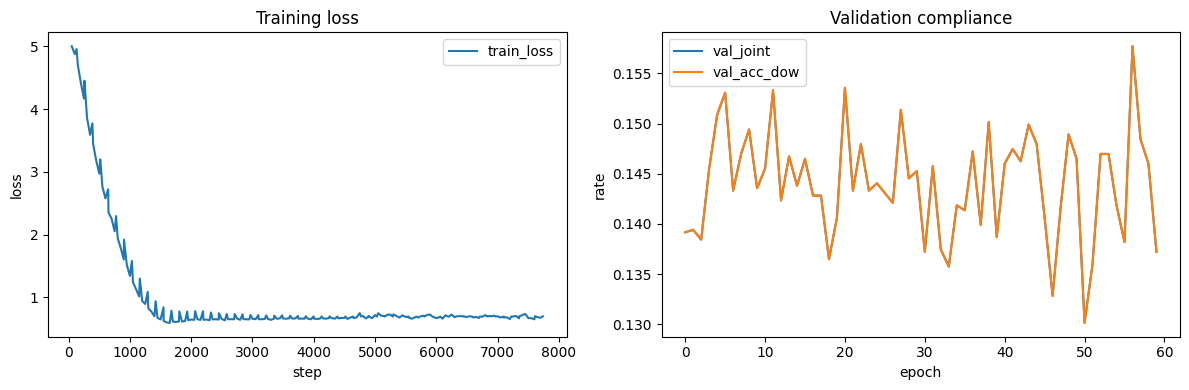

In [5]:
# Plot training loss + val joint compliance.
import json, matplotlib.pyplot as plt, pathlib
rows = [json.loads(l) for l in pathlib.Path("runs/cgan/log.jsonl").read_text().splitlines() if l.strip()]
ep_rows = [r for r in rows if r.get("val_joint_compliance") is not None]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([r["step"] for r in rows], [r["train_loss"] for r in rows], label="train_loss")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss"); ax[0].set_title("Training loss"); ax[0].legend()
ax[1].plot([r["epoch"] for r in ep_rows], [r["val_joint_compliance"] for r in ep_rows], label="val_joint")
ax[1].plot([r["epoch"] for r in ep_rows], [r["val_acc_dow"] for r in ep_rows], label="val_acc_dow")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("rate"); ax[1].set_title("Validation compliance"); ax[1].legend()
plt.tight_layout(); plt.show()
